# Entrega Final

 

# 1. Abstracto con motivación y audiencia

1. Abstracto con motivación y audiencia: Descripción de alto nivel de lo que motiva a analizar los datos elegidos y audiencia que se podría beneficiar de este análisis.

2. Preguntas/Problema que buscamos resolver: Si bien puede haber más de una problemática a resolver, la problemática principal debe encuadrarse como un problema de clasificación o regresión.

3. Breve Análisis Exploratorio de Datos (EDA): Análisis descriptivo de los datos mediante visualizaciones y herramientas estadísticas, análisis de valores faltantes.

4. Ingeniería de atributos: Creación de nuevas variables, transformación de variables existentes (i.e normalización de variables, encoding, etc.)

5. Entrenamiento y Testeo: Entrenamiento y testeo de al menos 2 modelos distintos de Machine Learning utilizando algún método de validación cruzada.

6. Optimización: Utilizar alguna técnica de optimización de hiperparámetros (e.g gridsearch, randomizedsearch, etc.)


<div style="text-align: justify;">
En el siguiente notebook se trabajará con un conjunto de datos provenientes de Monitoreo Acústico Pasivo (PAM) en una locación al sur de Chile.
El PAM consiste en el uso de unidades de grabación autonomas para el registro de datos de audio en terreno. Los datos usados en este proyecto fueron extraidos de grabaciones realizadas según un esquema de 1 minuto cada 5 minutos 24 horas al día durante 3 días. Esta unidad de muestreo se repitió en 21 sitios separados por almenos 1 km.

El conjunto de datos proviene de un trabajo de Pattern Matching realizado en la plataforma online de arbimon.org de la Rainforest Connection (RFCx) la cual es una organización que busca construir e implementar sistemas de monitoreo acústico abiertos y escalables que puedan detener la tala ilegal y la caza furtiva, y pudiendo permitir la medición y el monitoreo de la biodiversidad.

Es en este último punto en el cual se enfoca el presente análisis, en el cual para estimar la diversidad de especies se realizó un análisis de Pattern Matching. Este consiste en contruir un template o molde para cada especie de ave posible que habita el área de estudio, luego se construye un playlist con los audios en los cuales se quieren encontrar las coinsidencias con los templates creados. Finalmente se deben validar de forma manual las coinsidencias, asignandoles uno de tres estados; presente, no presente o no validado. 
Los resultados de este análisis se pueden descargar en un archivo csv por cada template (uno por cada especie de ave) en el cual cada registro contiene los siguientes campos:

</div>

* **id:** identificador único de cada coincidencia, validada o no.
* **recording:** nombre de la grabación donde se encontró la coincidencia
* **site:** nombre del sitio de la grabación
* **fecha:** year, month, day, hour, minute
* **species:** nombre científico de la especie 
* **songtype:** tipo de vocalización del ave
* **x1, x2:** tiempo de inicio y fin de la conicidencia
* **y1, y2:** frecuancias máxima y mínima de la coincidencia
* **frequency:** frecunecia máxima de la grabación
* **validated:** present, not present o (not validated)
* **url:** url de la grabación
* **score:** puntaje de la considencia que va de 0 a 1, siendo 1 la coincidencia máxima
* **site_id:** identifacador único del sitio

# 2. Preguntas/Problema que buscamos resolver

Si bien puede haber más de una problemática a resolver, la problemática principal debe encuadrarse como un problema de clasificación o regresión.

**Respecto a las especies**
1. ¿Cuántas especies se encontraron?
2. ¿Cuáles son las especies más abundates?


**Respecto al tiempo**
1. ¿Cual día es el con más presencia de especies?
2. ¿Cómo varía el número de especies presentes a lo largo de los días?
3. ¿Cómo varía el número de especies presentes cada 24 horas?


**Respecto al espacio**
1. ¿En que sitios se detectó la presencia de más especies?
2. ¿Existe algún patrón espacial en la presencia de especies?

# 3. Preparación Datos

## 1. Limpieza 

In [29]:
# importar y unir csv

import pandas as pd
import glob
import os

# Ruta de la carpeta donde están los CSV de cada especie
carpeta = r'C:\Users\camil\OneDrive - Universidad Austral de Chile\analisis_tesis\riqueza\chanchan_015'  

# Buscar todos los archivos CSV en la carpeta
archivos_csv = glob.glob(os.path.join(carpeta, '*.csv'))

# Leer y concatenar todos los CSV en un solo DataFrame
df = pd.concat([pd.read_csv(f) for f in archivos_csv], ignore_index=True)

# Guardar el DataFrame combinado en un nuevo CSV
df.to_csv(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\reporte_riqueza.csv', index=False)


In [30]:
#df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112098 entries, 0 to 112097
Data columns (total 19 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         112098 non-null  int64  
 1   recording  112098 non-null  object 
 2   site       112098 non-null  object 
 3   year       112098 non-null  int64  
 4   month      112098 non-null  int64  
 5   day        112098 non-null  int64  
 6   hour       112098 non-null  int64  
 7   minute     112098 non-null  int64  
 8   species    112098 non-null  object 
 9   songtype   112098 non-null  object 
 10  x1         112098 non-null  float64
 11  x2         112098 non-null  float64
 12  y1         112098 non-null  int64  
 13  y2         112098 non-null  int64  
 14  frequency  112098 non-null  int64  
 15  validated  112098 non-null  object 
 16  url        112098 non-null  object 
 17  score      112098 non-null  float64
 18  site_id    112098 non-null  int64  
dtypes: float64(3), int64(10

In [31]:
# Esto mostrará únicamente las filas que tienen uno o más valores faltantes (NaN o None) en cualquier columna del DataFrame

registros_con_nulos = df[df.isnull().any(axis=1)]
print(registros_con_nulos)


Empty DataFrame
Columns: [id, recording, site, year, month, day, hour, minute, species, songtype, x1, x2, y1, y2, frequency, validated, url, score, site_id]
Index: []


No se encintraron valores nulos.

Para un mejor entendimiento de los datos se realizará un reporte con la librería *sweetviz*.

In [76]:
import sweetviz as sv

# Generar el reporte de Sweetviz

reporte = sv.analyze(df)
reporte.show_html(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\reporte_riqueza.html')


                                             |          | [  0%]   00:00 -> (? left)

Report C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\reporte_riqueza.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**URL del reporte:**

 file:///C:/Users/camil/OneDrive%20-%20Universidad%20Austral%20de%20Chile/datascience1/proyectoDS_parte1/Data_Science_ll/entrega_1/reporte_riqueza.html

**Insights**

* 11,326 presencias
* 100,472 not present
* 300 not validated 

* 21 sitios

* 30 especies

* Score
    * MAX   0.956
    * MIN   0.150
    * AVG   0.219
    * MED   0.342

Dado que el trabajo se centra en evaluar la dinámica temporal espacial y temporal de las aves, se trbajará solo con los registros validados como presentes.

In [32]:
# crear df con solo presencias

df_validated = df[df['validated'] == 'present']
df_validated.head()

,id,recording,site,year,month,day,hour,minute,species,songtype,x1,x2,y1,y2,frequency,validated,url,score,site_id
1255,1012265410,SMM09595_20231008_144000.wav,P37-SMM09595,2023,10,8,14,40,Anairetes parulus,Common Song,5.5680,6.92267,1875,5578,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.335732,53992
1553,1012268009,SMM09360_20231010_104000.wav,P23_SMM09360,2023,10,10,10,40,Anairetes parulus,Common Song,21.1627,22.51730,1875,5578,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.403137,48816
1916,1012274410,SMM09360_20231009_182500.wav,P23_SMM09360,2023,10,9,18,25,Anairetes parulus,Common Song,31.4560,32.81070,1875,5578,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.464491,48816
1967,1012274461,SMM09360_20231009_085500.wav,P23_SMM09360,2023,10,9,8,55,Anairetes parulus,Common Song,57.0240,58.37870,1875,5578,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.257202,48816
1970,1012274464,SMM09360_20231009_085000.wav,P23_SMM09360,2023,10,9,8,50,Anairetes parulus,Common Song,56.3947,57.74930,1875,5578,12000,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.453465,48816


In [ ]:
# crear columna datetime a partir de year, month, day, hour y minute
 
df_validated['datetime'] = pd.to_datetime(df_validated[['year', 'month', 'day', 'hour', 'minute']])
df_validated.head()

In [34]:
# eliminar columnas innecesarias

# las siguientes columnas no son necesarias para el análisis, ya que están fuera de los objetivos del proyecto.

df_validated = df_validated.drop(columns=['songtype', 'x1', 'x2', 'y1', 'y2', 'frequency'])
df_validated.head()

,id,recording,site,year,month,day,hour,minute,species,validated,url,score,site_id,datetime
1255,1012265410,SMM09595_20231008_144000.wav,P37-SMM09595,2023,10,8,14,40,Anairetes parulus,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.335732,53992,2023-10-08 14:40:00
1553,1012268009,SMM09360_20231010_104000.wav,P23_SMM09360,2023,10,10,10,40,Anairetes parulus,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.403137,48816,2023-10-10 10:40:00
1916,1012274410,SMM09360_20231009_182500.wav,P23_SMM09360,2023,10,9,18,25,Anairetes parulus,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.464491,48816,2023-10-09 18:25:00
1967,1012274461,SMM09360_20231009_085500.wav,P23_SMM09360,2023,10,9,8,55,Anairetes parulus,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.257202,48816,2023-10-09 08:55:00
1970,1012274464,SMM09360_20231009_085000.wav,P23_SMM09360,2023,10,9,8,50,Anairetes parulus,present,https://rfcx-streams-production.s3.eu-west-1.a...,0.453465,48816,2023-10-09 08:50:00


In [35]:
# guradar df_validated en un nuevo csv
df_validated.to_csv(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_validados.csv', index=False)

Para finalizar la etapa de limpieza se volverá a crear un reporte con sweetviz, pero esta vez para comparar el datafreme de inicio (crudo) con el actual (limpio)

In [ ]:
# reporte de comparación

import sweetviz as sv
df1 = pd.read_csv(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\reporte_riqueza.csv')
df2 = pd.read_csv(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_validados.csv')

# Opcional: puedes dar nombres a los DataFrames para que aparezcan en el reporte
reporte = sv.compare([df1, "Crudo"], [df2, "Limpio"])

reporte.show_html("reporte_comparacion.html")


**URL del reporte:** file:///C:/Users/camil/OneDrive%20-%20Universidad%20Austral%20de%20Chile/datascience1/proyectoDS_parte1/Data_Science_ll/entrega_1/reporte_comparacion.html


**Insights**

* 11,326 presencias

* 21 sitios

* 30 especies

* Score
    * MAX   0.956
    * MIN   0.150
    * AVG   0.358
    * MED   0.342

## 2. Formato

Para poder trabajar de mejor forma la variabilidad temporal se homogeneizarán los intervalos de tiempo. Esto dado que algunas horas están sub representadas (noche y madrugada) y otras sobrerepresentadas (mañana y tarde). Para esto se remuestraran cada 5 minutos.

Luego se creará una columna llamada 'species_count' para poder contar el número de especies presentes en cada unidad de tiempo y sitio, esto con el fin de facilitar los análisis posteriores.

In [44]:
import pandas as pd
import numpy as np

# Cargar el archivo CSV limpio y validado
data_path = r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_validados.csv'
data = pd.read_csv(data_path)
data['datetime'] = pd.to_datetime(data['datetime'])


# Redondear o truncar los valores datetime al intervalo de 5 minutos más cercano (hacia abajo)
data['datetime_5min'] = data['datetime'].dt.floor('5T')

# Crear un rango completo de datetime cada 5 minutos desde el mínimo al máximo
start_date = pd.to_datetime('2023-10-08 00:00:00') # Fecha mínima del df
end_date = pd.to_datetime('2023-10-10 23:55:00') # Fecha máxima del df
date_range = pd.date_range(start=start_date, end=end_date, freq='5T')

# Obtener lista única de sites
sites = data['site'].unique()

# Crear todas las combinaciones posibles de datetime cada 5 minutos y site
from itertools import product
all_combinations = pd.DataFrame(product(date_range, sites), columns=['datetime_5min', 'site'])

# Agrupar el DataFrame original para contar especies únicas por datetime_5min y site
grouped = data.groupby(['datetime_5min', 'site'])['species'].nunique().reset_index()
grouped = grouped.rename(columns={'species': 'species_count'})

# Hacer merge para tener todas las combinaciones y rellenar con 0 donde no haya datos
result = pd.merge(all_combinations, grouped, on=['datetime_5min', 'site'], how='left')
result['species_count'] = result['species_count'].fillna(0).astype(int)

result

C:\Users\camil\AppData\Local\Temp\ipykernel_11192\4073518454.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data['datetime_5min'] = data['datetime'].dt.floor('5T')
C:\Users\camil\AppData\Local\Temp\ipykernel_11192\4073518454.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range = pd.date_range(start=start_date, end=end_date, freq='5T')


,datetime_5min,site,species_count
0,2023-10-08 00:00:00,P37-SMM09595,0
1,2023-10-08 00:00:00,P23_SMM09360,0
2,2023-10-08 00:00:00,P07-SMM09344,0
3,2023-10-08 00:00:00,P04_SMM09557,0
4,2023-10-08 00:00:00,P19_SMM09396,0
...,...,...,...
18139,2023-10-10 23:55:00,P02_SMM09261,0
18140,2023-10-10 23:55:00,P26_SMM09319,0
18141,2023-10-10 23:55:00,P20_SMM09279,0
18142,2023-10-10 23:55:00,P43-SMM09315,0


In [45]:
result.to_csv(r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_5min.csv', index=False)

# 4. EDA

## Respecto a las especies

Para esto se trabajará con el dataframe que contiene solo los validado como presente y sin re muestrear cada 5 min

In [ ]:
file_path = r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_validados.csv'

df = pd.read_csv(file_path)

unique_species_count = df['species'].nunique()
print(f"Número de valores únicos en la columna 'species': {unique_species_count}")

Número de valores únicos en la columna 'species': 30


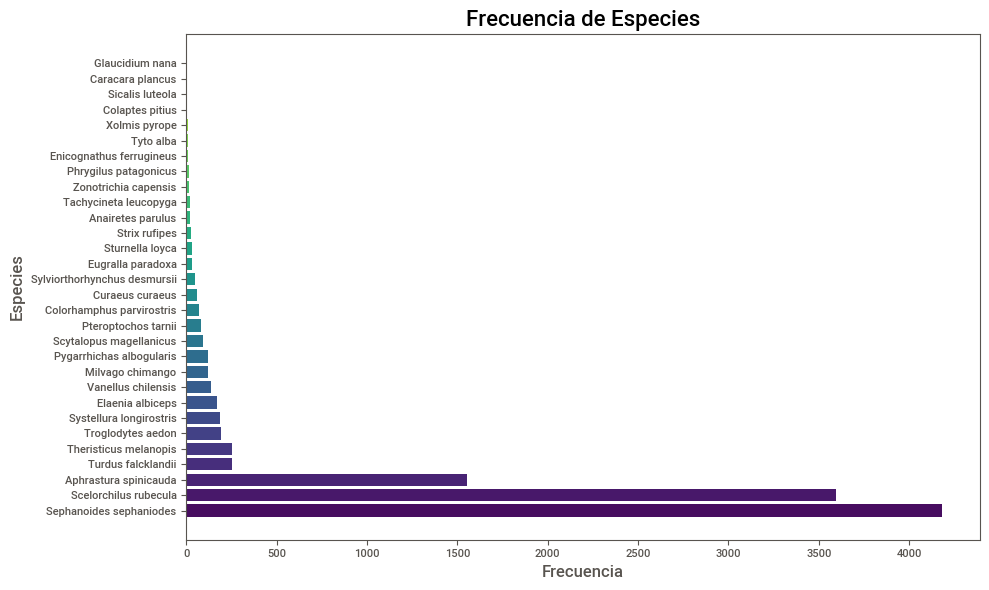

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns


# Obtener la paleta viridis con la cantidad de especies
palette = sns.color_palette("viridis", n_colors=len(species_counts))

plt.figure(figsize=(10, 6))
plt.barh(species_counts.index, species_counts.values, color=palette)
plt.title('Frecuencia de Especies', fontsize=16)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Especies', fontsize=12)
plt.tight_layout()
plt.show()


**Insights**

Durante el periodo de tiempo estudiado, se detectó la presencia de un total de **30 especies de aves distintas**, siendo *Sephanoides sephaniodes*, *Scelorchilus rubecula* y *Aphrastura spinicauda* las más abundantes.

## Respecto al tiempo

Para estos análisis se utilizará el conjunto de datos remuestrados cada 5 minutos.

In [46]:
file_path = r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_5min.csv'

df = pd.read_csv(file_path)

# Convertir la columna 'datetime_5min' a tipo datetime solo para asegurarse
df['datetime_5min'] = pd.to_datetime(df['datetime_5min'])
# Convertir la columna 'site' a tipo categórico para optimizar el uso de memoria
df['site'] = df['site'].astype('category')

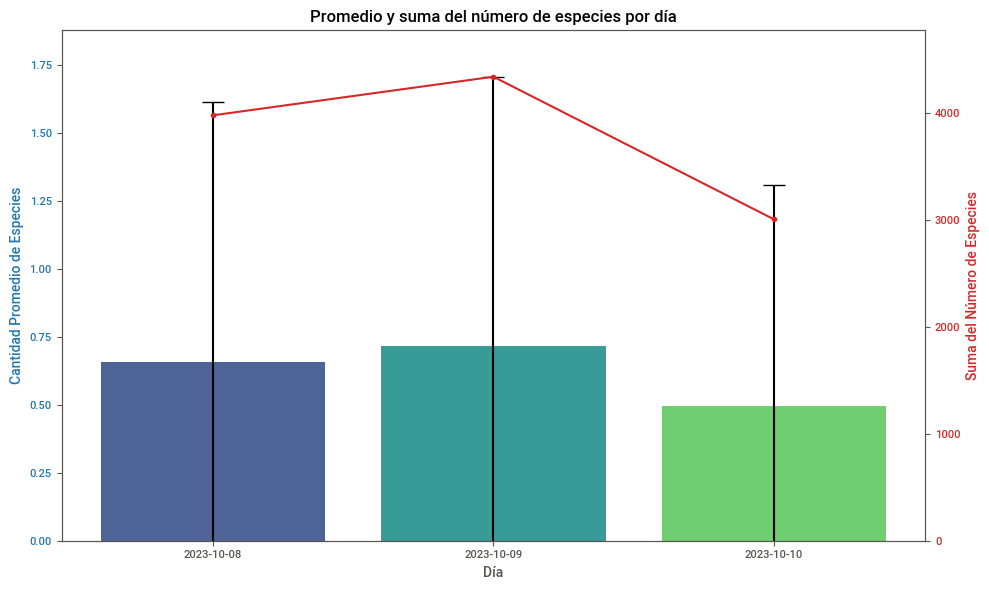

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Agrupar datos: calcular media, std y suma por día
df_stats = df.groupby('day')['species_count'].agg(['mean', 'std', 'sum']).reset_index()

# Paleta viridis para barras
palette = sns.color_palette("viridis", n_colors=len(df_stats))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras: promedio con desviación estándar
bars = ax1.bar(df_stats['day'].astype(str), df_stats['mean'], yerr=df_stats['std'], 
               color=palette, capsize=8, alpha=0.9, label='Promedio')

ax1.set_xlabel('Día')
ax1.set_ylabel('Cantidad Promedio de Especies', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Ajustar límite del eje Y primario de 0 al máximo + margen
max_mean = (df_stats['mean'] + df_stats['std']).max()
ax1.set_ylim(0, max_mean * 1.1)

# Eje secundario para la suma
ax2 = ax1.twinx()
ax2.plot(df_stats['day'].astype(str), df_stats['sum'], color='tab:red', marker='o', label='Suma')
ax2.set_ylabel('Suma del Número de Especies', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Ajustar límite del eje Y secundario de 0 al máximo + margen
max_sum = df_stats['sum'].max()
ax2.set_ylim(0, max_sum * 1.1)

# Título y layout
plt.title('Promedio y suma del número de especies por día')
fig.tight_layout()
plt.show()



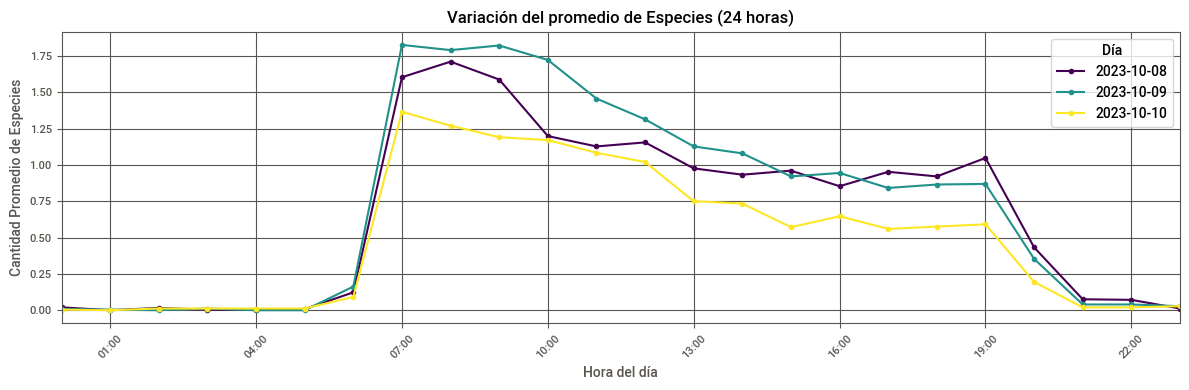

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

# Asegúrarse de que datetime_5min sea datetime
df['datetime_5min'] = pd.to_datetime(df['datetime_5min'])

# Extraer la hora redondeada
df['hora'] = df['datetime_5min'].dt.hour

# Calcular el promedio (o suma) de species_count por hora y día
df_agg = df.groupby(['day', 'hora'])['species_count'].mean().reset_index()

# Crear una columna datetime para graficar (usando fecha base)
fecha_base = pd.Timestamp('2023-01-01')
df_agg['time_dt'] = fecha_base + pd.to_timedelta(df_agg['hora'], unit='h')

# Grafica una línea por día usando paleta viridis
fig, ax = plt.subplots(figsize=(12, 4))

# Obtener días únicos y crear colores de la paleta viridis
days = df_agg['day'].unique()
colors = cm.viridis(np.linspace(0, 1, len(days)))

# Graficar cada día con un color de la paleta viridis
for i, (day, group) in enumerate(df_agg.groupby('day')):
    ax.plot(group['time_dt'], group['species_count'], marker='o', 
            label=str(day), color=colors[i])

# Configura el eje x de 00:00 a 23:00 y etiquetas cada 3 horas
ax.set_xlim(fecha_base, fecha_base + pd.Timedelta(hours=23))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xlabel('Hora del día')
plt.ylabel('Cantidad Promedio de Especies')
plt.title('Variación del promedio de Especies (24 horas)')
plt.legend(title='Día')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insights**

blj
bljv
fc

## Respecto al espacio

Para estos análisis se utilizará el conjunto de datos remuestrados cada 5 minutos.

C:\Users\camil\AppData\Local\Temp\ipykernel_11192\1516671435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='site', y='species_count', data=site_counts,


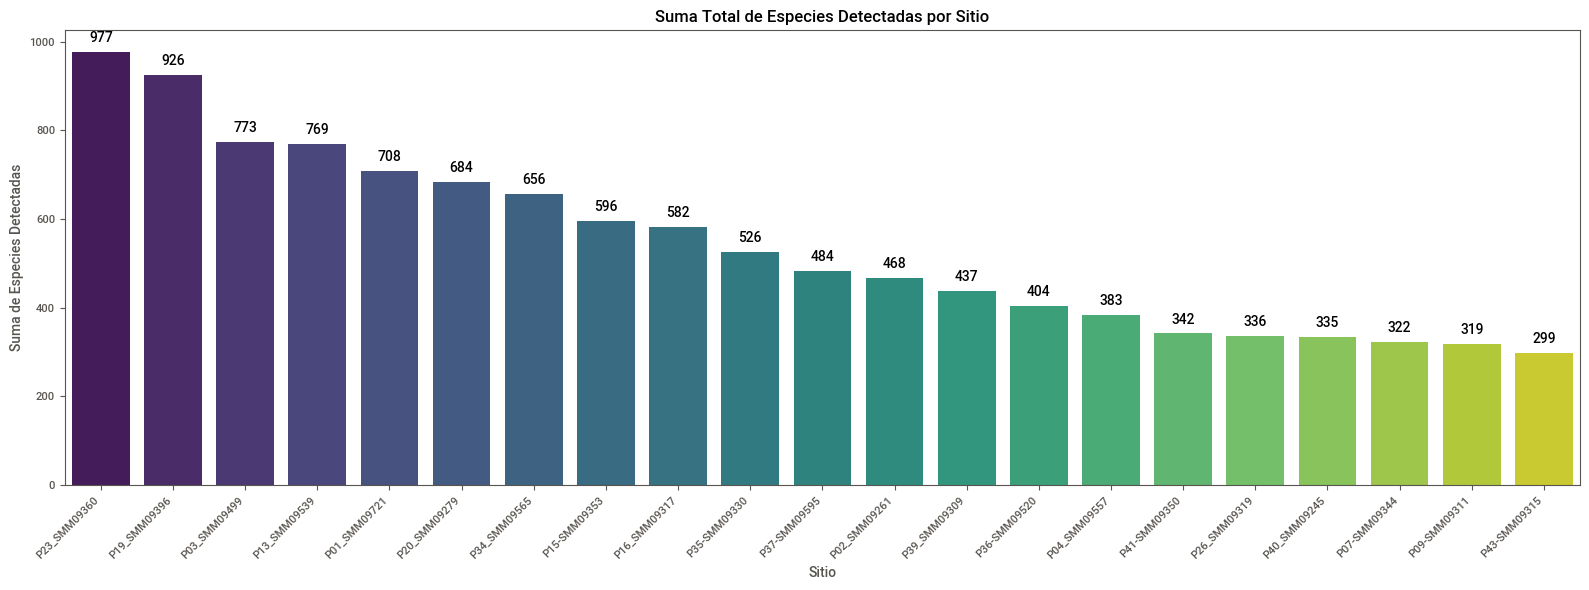

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar y ordenar
site_counts = df.groupby('site', observed=True)['species_count'].sum().reset_index()
site_counts = site_counts.sort_values(by='species_count', ascending=False)

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='site', y='species_count', data=site_counts,
                 order=site_counts['site'], palette="viridis")

plt.title('Suma Total de Especies Detectadas por Sitio')
plt.xlabel('Sitio')
plt.ylabel('Suma de Especies Detectadas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agregar los valores encima de cada barra, usando los patches del gráfico
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 puntos arriba
                textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()






**Insights**

jfg

jgfj

khhg

# 5. Implementación Machine Learning

Para esta sección se utilizarán los registros de una especie objetivo (*Scelorchilus rubecula*) con el fin de evaluar si exsiten efectos de las horas y/o sitios en la detección de esta especie.

Para lograr estos objetivos se pondrán implementarán dos modelos de Machine Learning: 1) Regresión Logistica y 2) Árbol de Decisiones.

## 1. Preparación de Datos

In [ ]:
# Preparar datos

import pandas as pd

file = r'C:\Users\camil\OneDrive - Universidad Austral de Chile\datascience1\proyectoDS_parte1\Data_Science_ll\entrega_1\riqueza_validados.csv'

df = pd.read_csv(file)

species_filtrar = ['Sephanoides sephaniodes', 'Scelorchilus rubecula', 'Aphrastura spinicauda']
df_filtrado = df[df['species'].isin(species_filtrar)]
df_filtrado['datetime'] = pd.to_datetime(df_filtrado['datetime'])

# Unificar separador en la columna 'site': reemplazar '-' por '_'
df_filtrado['site'] = df_filtrado['site'].str.replace('-', '_', regex=False)
df_filtrado

In [ ]:
# Extraer el código de sitio

import pandas as pd

df_filtrado['site_code'] = df_filtrado['site'].str.split('_').str[0]



C:\Users\camil\AppData\Local\Temp\ipykernel_2608\1626448775.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['site_code'] = df_filtrado['site'].str.split('_').str[0]


In [ ]:
# Generar todas las combinaciones posibles de sitio y hora

import itertools

sites = df_filtrado['site_code'].unique()
hours = range(24)  # Horas del día de 0 a 23

all_combinations = pd.DataFrame(list(itertools.product(sites, hours)), columns=['site_code', 'hour'])


In [ ]:
# Contar detecciones por sitio y hora para una especie específica

## Elegir la especie de interés
especie_objetivo = 'Scelorchilus rubecula'

## Filtrar solo esa especie
df_esp = df_filtrado[df_filtrado['species'] == especie_objetivo]

## Contar detecciones por sitio y hora
detections = df_esp.groupby(['site_code', 'hour']).size().reset_index(name='count')


In [ ]:
# Unir y rellenar ausencias con ceros

df_full = all_combinations.merge(detections, on=['site_code', 'hour'], how='left').fillna(0)
df_full['count'] = df_full['count'].astype(int)
df_full['presence'] = (df_full['count'] > 0).astype(int)

In [ ]:
# Codificar variables categóricas para el modelo

## Codificar site_code como dummies (variables indicadoras)
df_model = pd.get_dummies(df_full, columns=['site_code'], drop_first=True)

In [71]:
df_model.head()

,hour,count,presence,site_code_P02,site_code_P03,site_code_P04,site_code_P07,site_code_P09,site_code_P13,site_code_P15,...,site_code_P23,site_code_P26,site_code_P34,site_code_P35,site_code_P36,site_code_P37,site_code_P39,site_code_P40,site_code_P41,site_code_P43
0,0,0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 2. Árbol de Decisiones

### Modelo

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy en test con mejor modelo: 0.980

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       0.97      1.00      0.98        60

    accuracy                           0.98       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.98      0.98      0.98       101



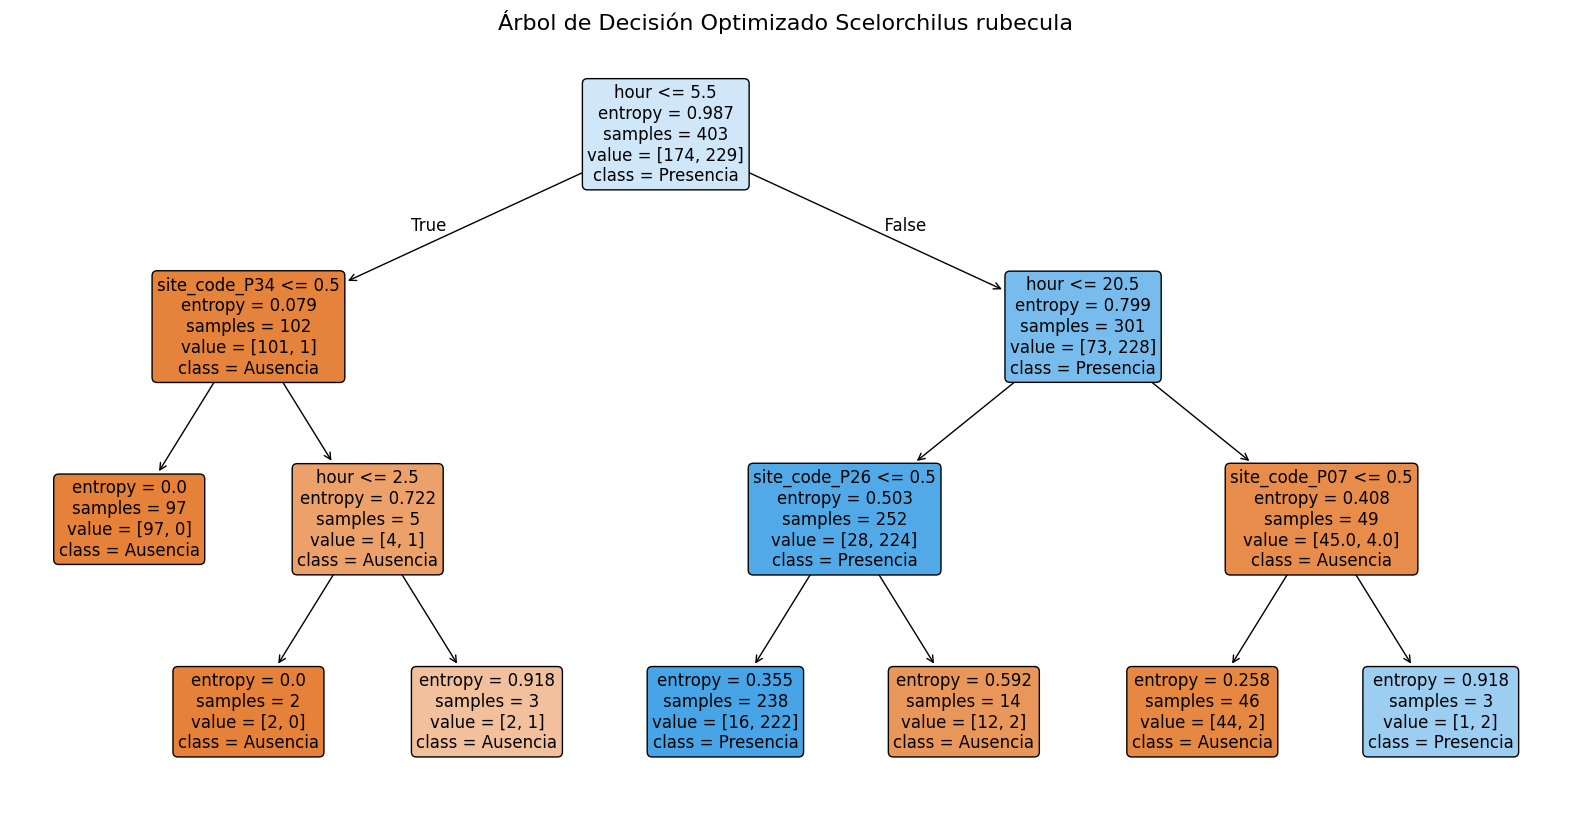

In [75]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Asumiendo df_model preparado con variables predictoras y target 'presence'
X = df_model.drop(columns=['count', 'presence'])
y = df_model['presence']

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir clasificador base
clf = DecisionTreeClassifier(random_state=42)

# Definir cuadrícula de hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV con validación cruzada
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Ejecutar búsqueda
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Modelo optimizado
best_clf = grid_search.best_estimator_

# Evaluar en test
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en test con mejor modelo: {accuracy:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Visualizar árbol optimizado
plt.figure(figsize=(20,10))
plot_tree(
    best_clf,
    feature_names=X.columns,
    class_names=['Ausencia', 'Presencia'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title(f'Árbol de Decisión Optimizado {especie_objetivo}', fontsize=16)
plt.show()


### Insights

### **1. Rendimiento del modelo**

* **Accuracy**: 98.0% - Rendimiento excepcional

* **Precision** clase 0 (Ausencia): 100% - Cuando predice ausencia, nunca se equivoca

* **Recall** clase 1 (Presencia): 100% - Detecta todas las presencias reales

* **F1-scores** balanceados: 0.97-0.98 para ambas clases

### **2. Hiperparámetros óptimos encontrados**

**Parámetro: Valor óptimo	-> Interpretación*

* **criterion**: 'entropy'  ->  Usa ganancia de información (mejor que Gini para esta especie)
* **max_depth**: 3  ->  Árbol simple pero muy efectivo (evita sobreajuste)
* **min_samples_leaf**: 1   ->  Permite nodos hoja con 1 muestra (máxima granularidad)
* **min_samples_split:** 2  ->  División mínima con 2 muestras (estándar)

### **Interpretación Árbol**

**Regla principal:** hora del día como factor dominante

* si hora ≤ 5.5 la especie está mayormente ausente
* si hora > 5.5 la especie es mucho más probable de detectar

**Reglas específicas**

* En horas tempranas (≤ 5.5): si no es P34 ausencia garantizada, si es sitio P34 excepciones en horas especificas.

* En horas avanzadas (> 5.5 y ≤ 20.5): si no es sitio P26 alta presencia, si es sitio P26 mayormente ausencia.

## 3. Regresión Logistica

### Modelo

In [73]:
# Ajustar modelo con statsmodels para obtener valores p y resumen estadístico

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import statsmodels.api as sm 

# Asegurarse que todas las columnas son numéricas y no hay NaN
X_train_sm = sm.add_constant(X_train)  # Añadir intercepto

# Convierte a float para evitar errores de tipo
X_train_sm = X_train_sm.astype(float)
y_train_sm = y_train.astype(float)

# Ajustar modelo logístico
model_sm = sm.Logit(y_train_sm, X_train_sm).fit(maxiter=1000)

# Mostrar resumen con coeficientes, errores estándar, valores p, etc.
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.613699
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               presence   No. Observations:                  403
Model:                          Logit   Df Residuals:                      381
Method:                           MLE   Df Model:                           21
Date:                Fri, 20 Jun 2025   Pseudo R-squ.:                  0.1144
Time:                        16:43:48   Log-Likelihood:                -247.32
converged:                       True   LL-Null:                       -279.28
Covariance Type:            nonrobust   LLR p-value:                 3.209e-06
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2481      0.506     -2.466      0.014      -2.240      -0.256
hour              0.

In [ ]:
# Ajustar una regresión logística para presencia/ausencia

# Entrenar modelo
modelo.fit(X_train, y_train)

# Predecir etiquetas y probabilidades en test
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {auc_roc:.3f}")

print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))


# Coeficientes
import numpy as np
coef = pd.Series(modelo.coef_[0], index=X.columns)
odds_ratios = np.exp(coef)
print("\nCoeficientes:")
print(coef)
print("\nOdds Ratios:")
print(odds_ratios)


Accuracy: 0.653
Precision: 0.618
Recall: 0.708
F1-score: 0.660
AUC-ROC: 0.625

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.70      0.60      0.65        53
           1       0.62      0.71      0.66        48

    accuracy                           0.65       101
   macro avg       0.66      0.66      0.65       101
weighted avg       0.66      0.65      0.65       101

Matriz de confusión:
 [[32 21]
 [14 34]]

Coeficientes:
hour             0.090044
site_code_P02    0.848634
site_code_P03    0.382241
site_code_P04    0.357531
site_code_P07    0.014556
site_code_P09    0.115159
site_code_P13    0.466055
site_code_P15   -0.092256
site_code_P16    0.464517
site_code_P19    0.379448
site_code_P20   -0.077513
site_code_P23    0.489444
site_code_P26   -1.032448
site_code_P34    0.382165
site_code_P35    0.066502
site_code_P36   -0.993730
site_code_P37   -0.785467
site_code_P39   -0.227834
site_code_P40    0.149875
site_code_P41    

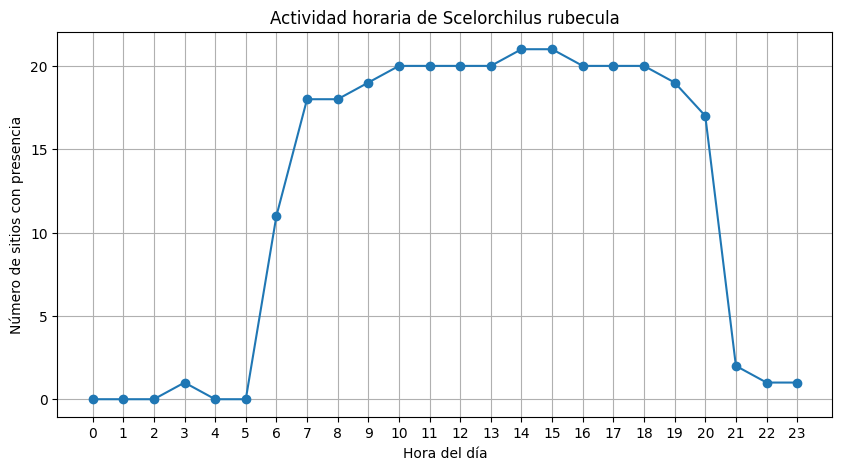

In [74]:
import matplotlib.pyplot as plt

# Suma de presencias por hora
actividad = df_full.groupby('hour')['presence'].sum()
plt.figure(figsize=(10,5))
plt.plot(actividad.index, actividad.values, marker='o')
plt.xlabel('Hora del día')
plt.ylabel('Número de sitios con presencia')
plt.title(f'Actividad horaria de {especie_objetivo}')
plt.xticks(range(24))
plt.grid()
plt.show()


### Insihgts

Los resultados muestran que el modelo tiene un bajo poder explicativo (Pseudo R² = 0.1144) y limitada significancia estadística.

* **Variables significativas**

**constante:** probabilidad base baja de presencia   
**hora:** fuertemente significativa +9.4% odds/hora

## Comparaciones Finales

### Rendimientos
En este apartado fue mejor el desempeño del Árbol de decisión (98% accuracy) en comparación con la Regresión Logistica (65% accuracy).

### Patrones
La Regresión Logistica solo pudo identificar patrones significativos a nivel de hora, mientras que al Árbol de Decisión pudo encontrar reglas complejas de hora y sitio.